Engineering trackside traffic window metrics...
-> Successfully mapped tyre telemetry data using database column: 'Compound'

     RANDOM FOREST TRAINING & OPTIMIZATION
Growing Random Forest ensemble step-by-step and logging metrics...


C:\Users\Pranay Krishna\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(
C:\Users\Pranay Krishna\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:861: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the r

🏆 RF Balanced F1 Threshold Selected: 23.50% (Validation Peak F1: 0.6133)

Extracted 25 valid tracks for 2025 campaign backtesting loops...

----------------------------------------------------------------------
 -> LAUNCHING 2025 RUNTIME BACKTEST: RANDOM FOREST PLOTS
----------------------------------------------------------------------


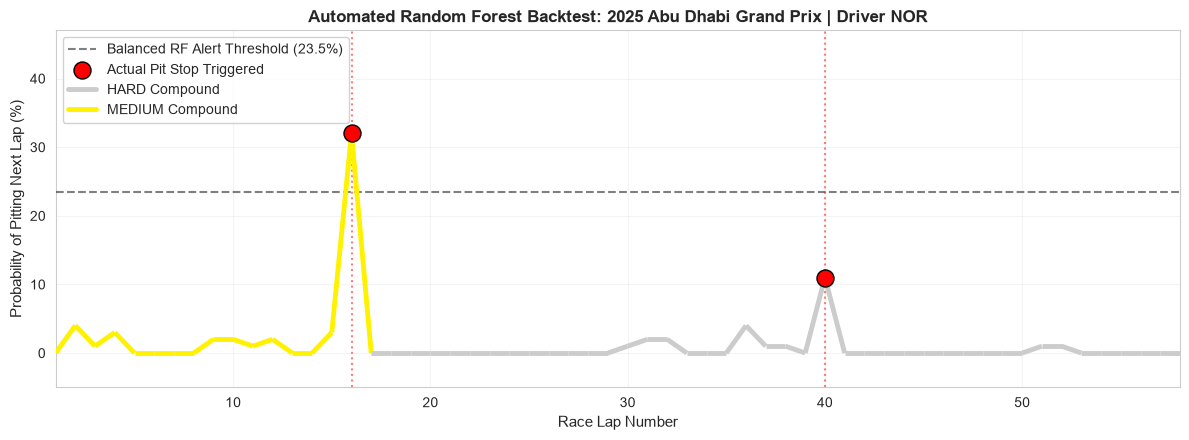

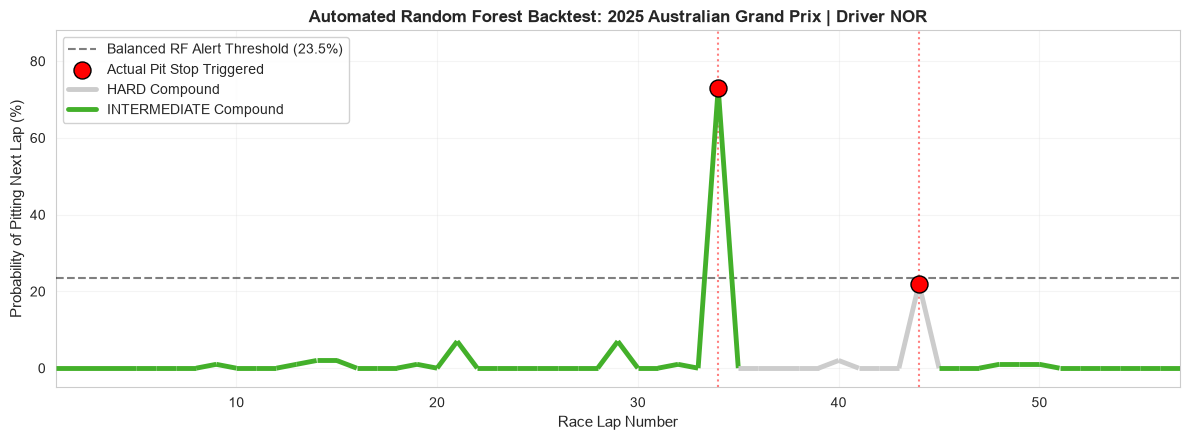

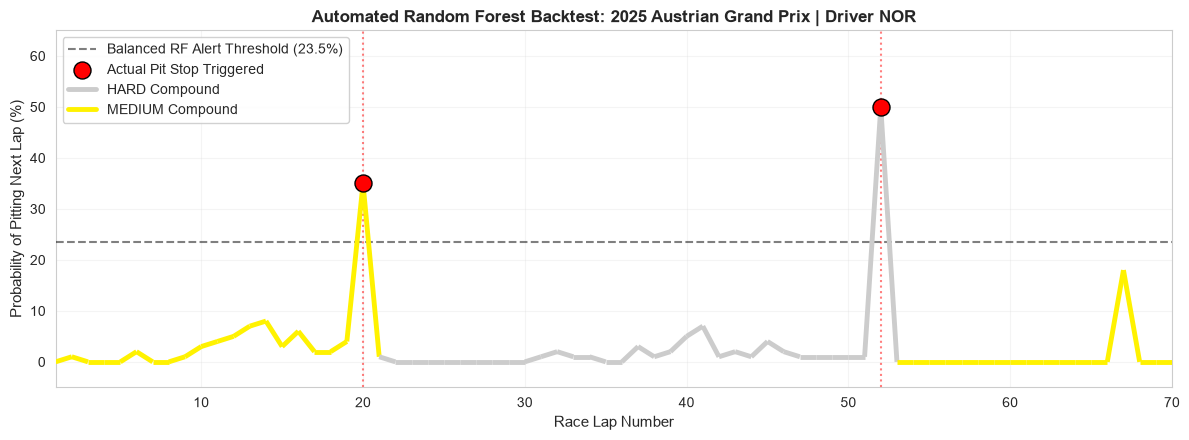

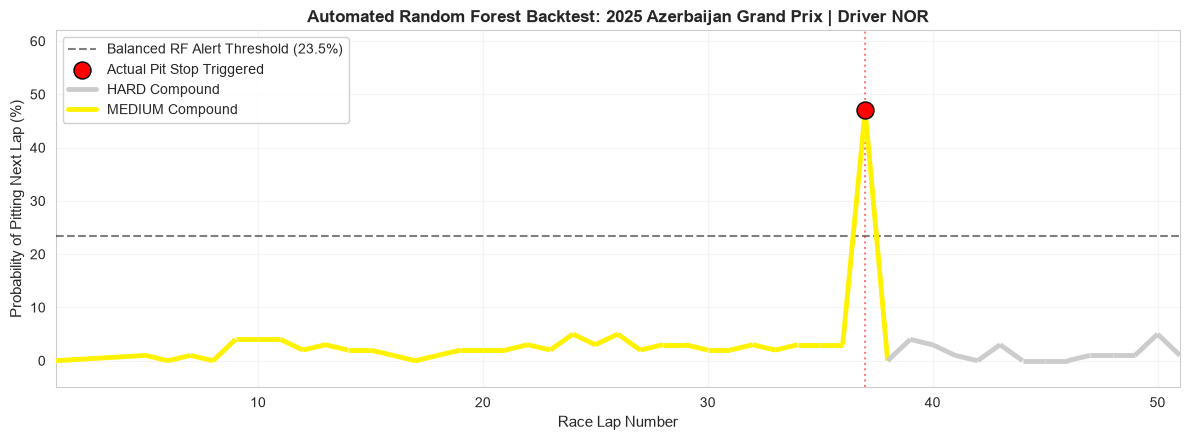

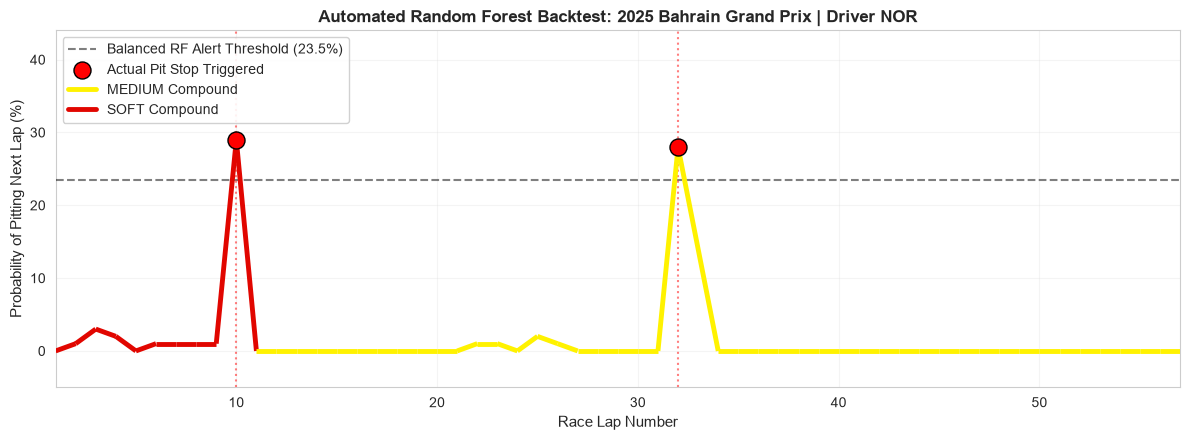

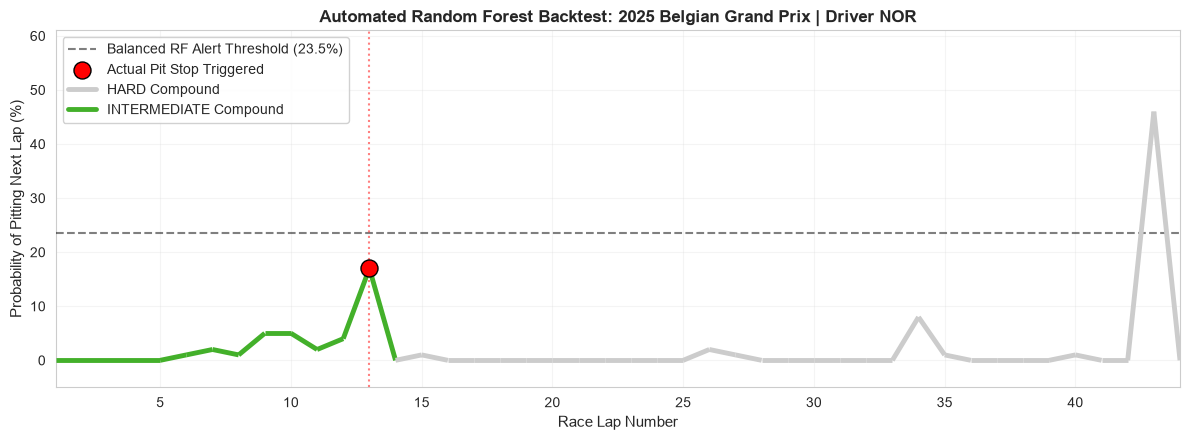

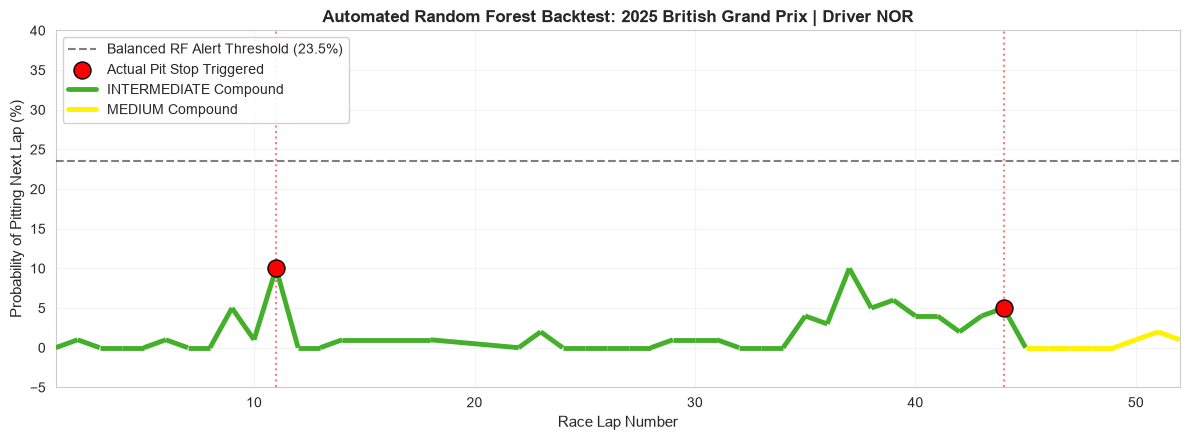

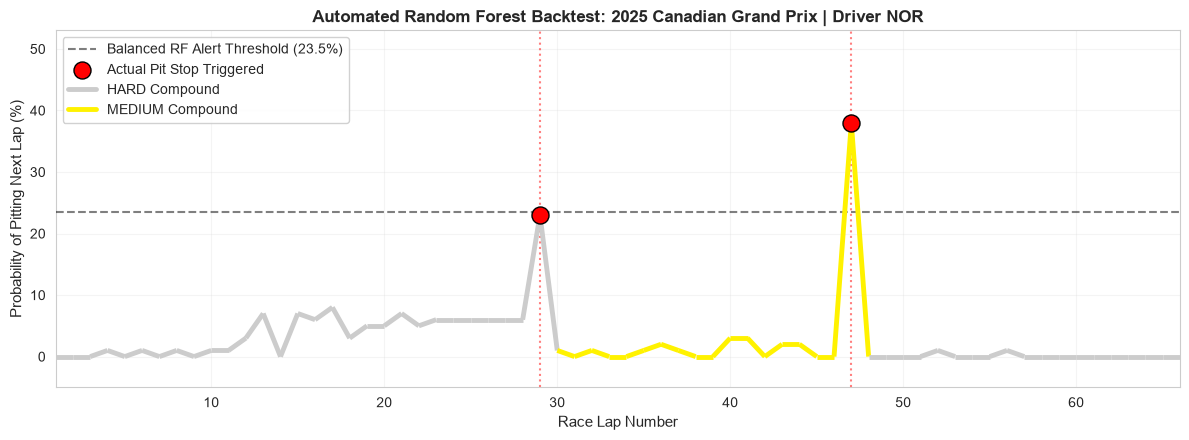

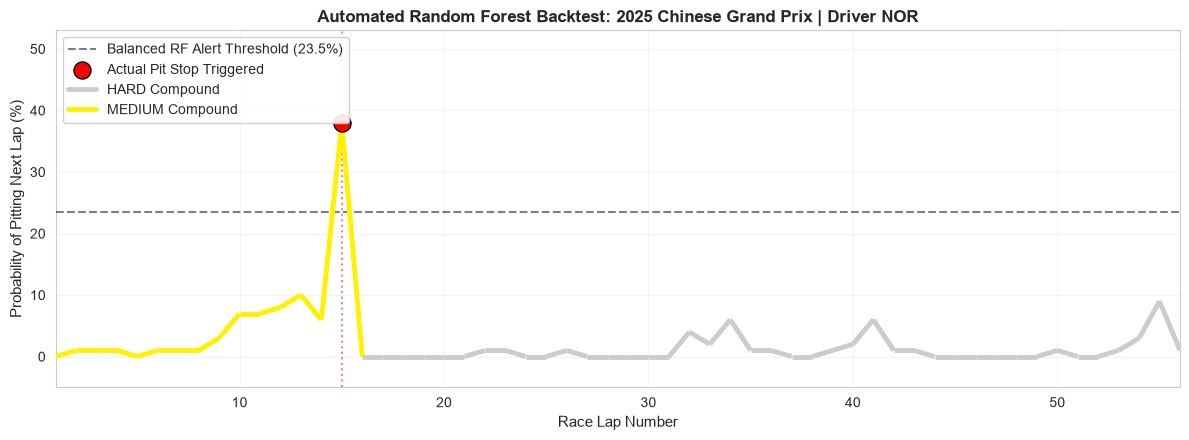

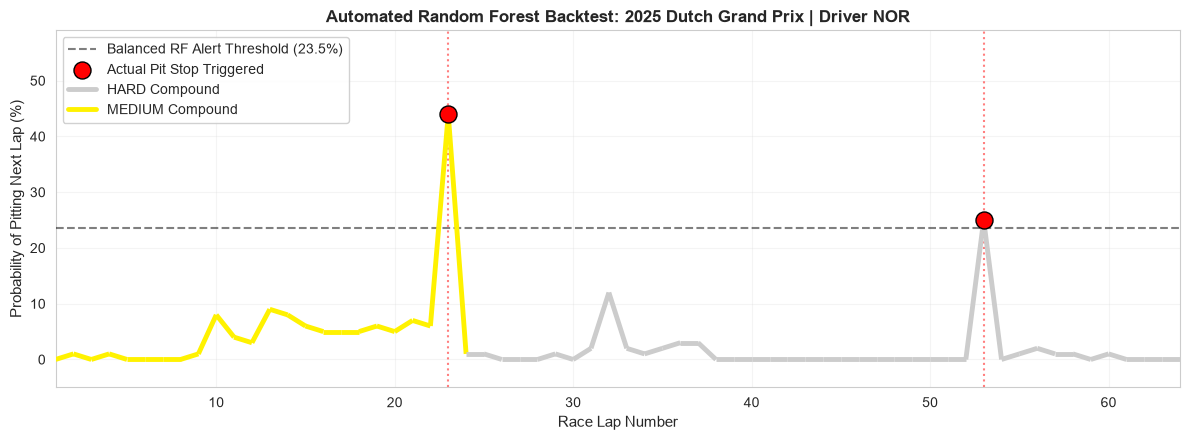

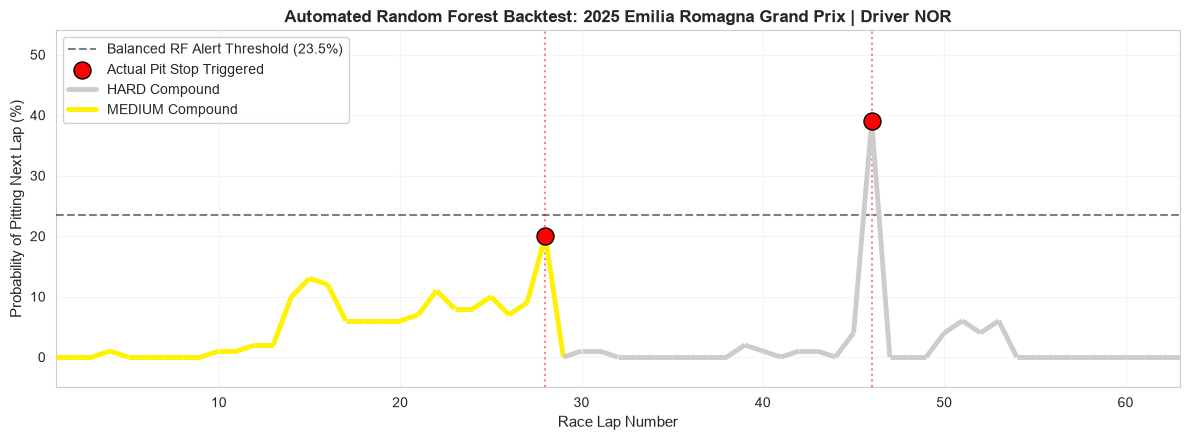

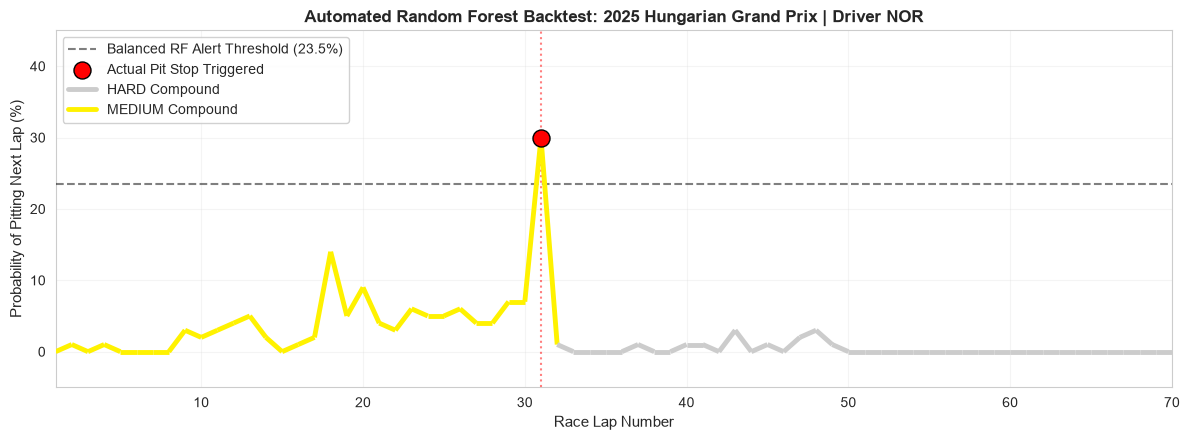

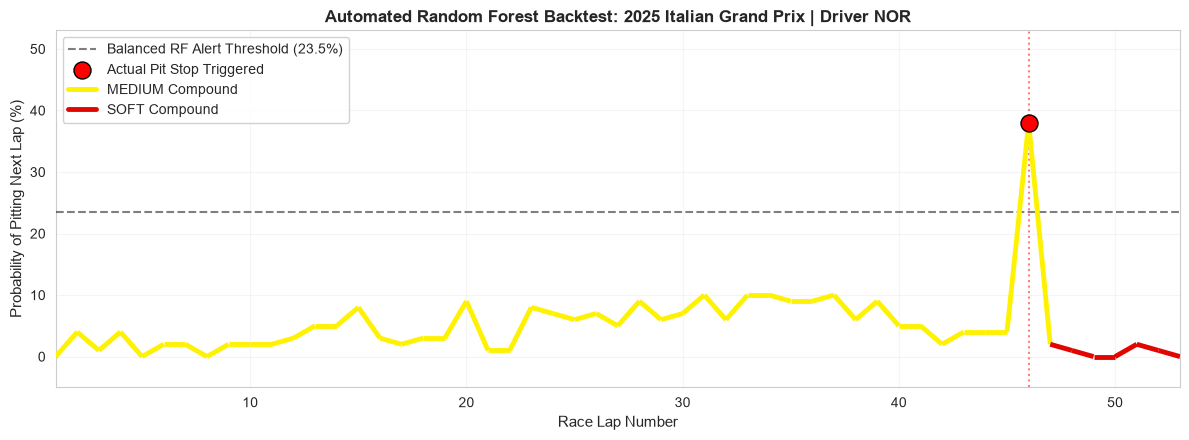

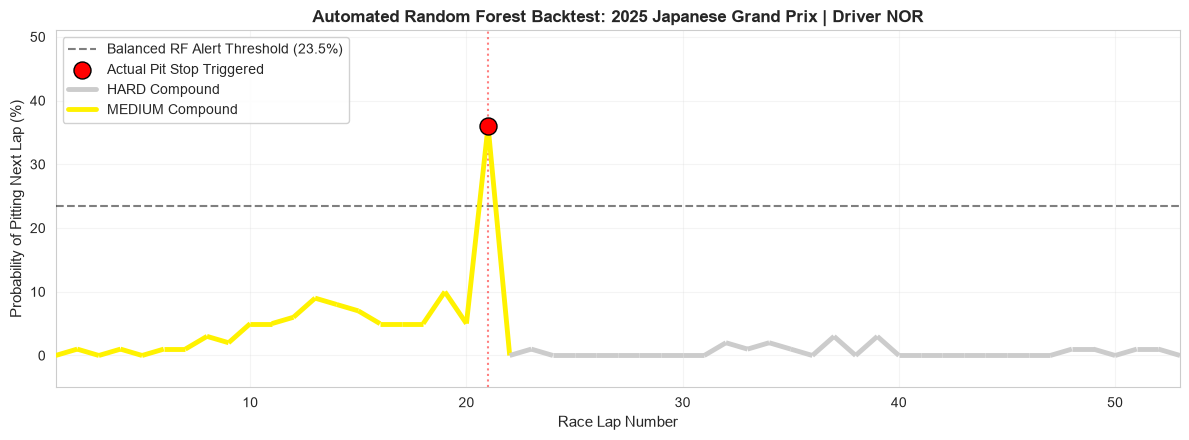

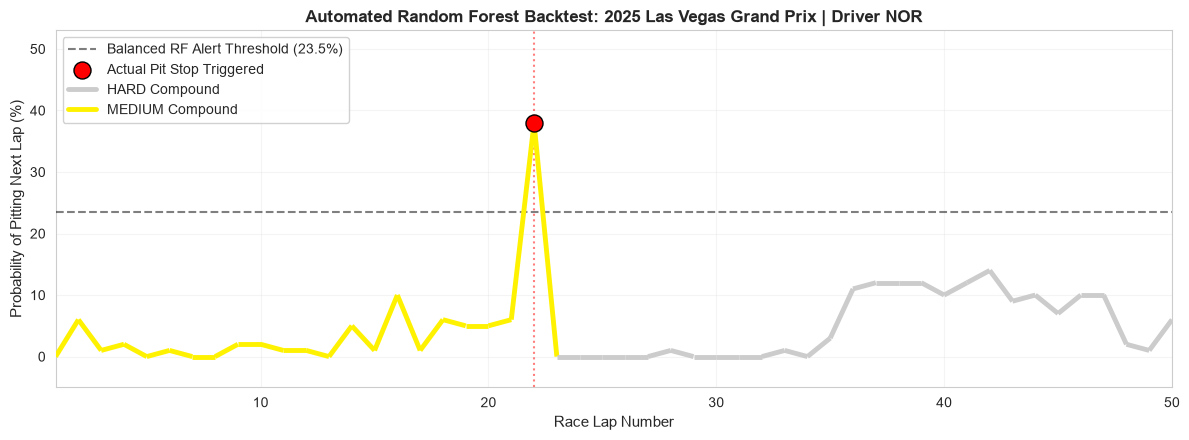

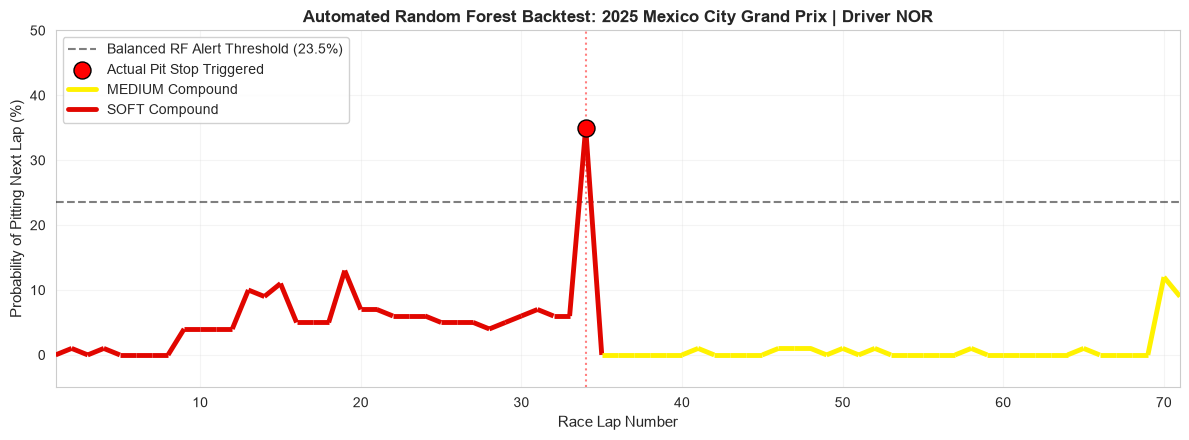

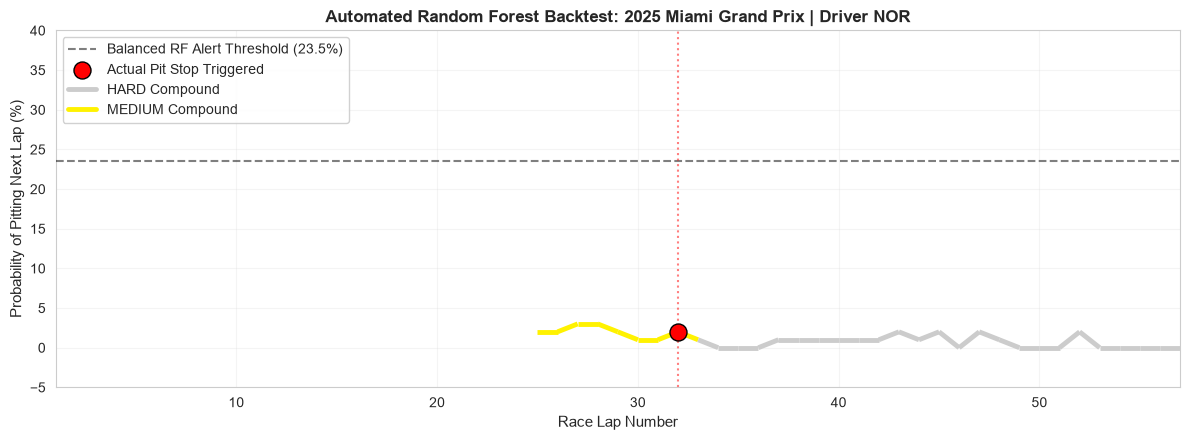

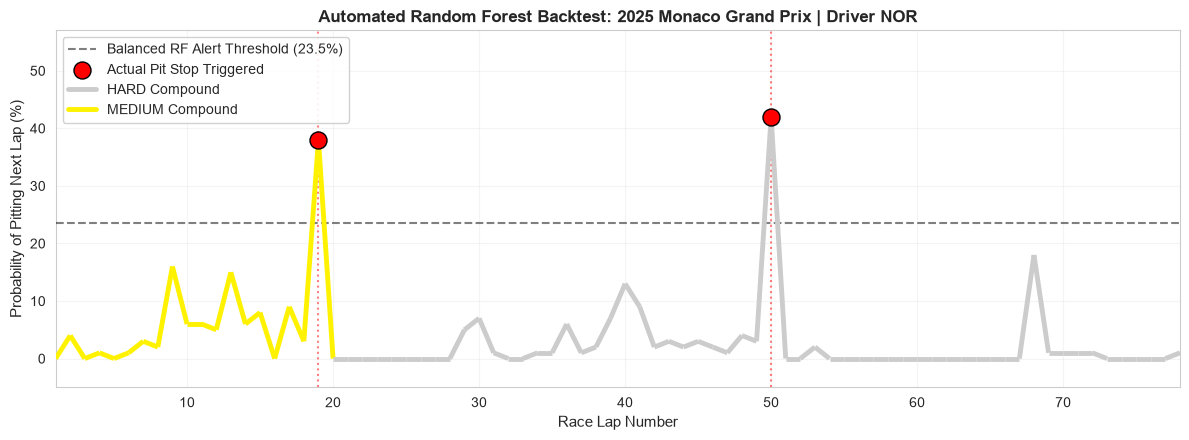

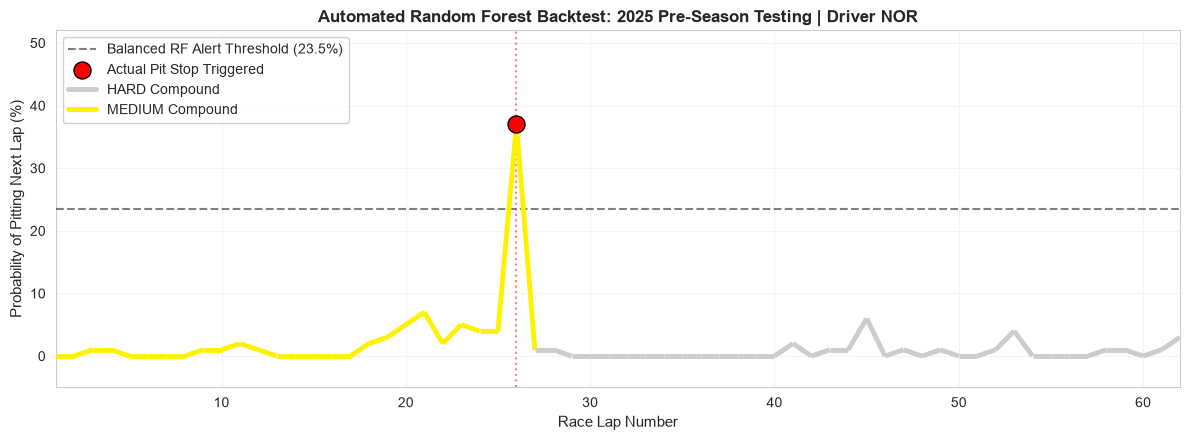

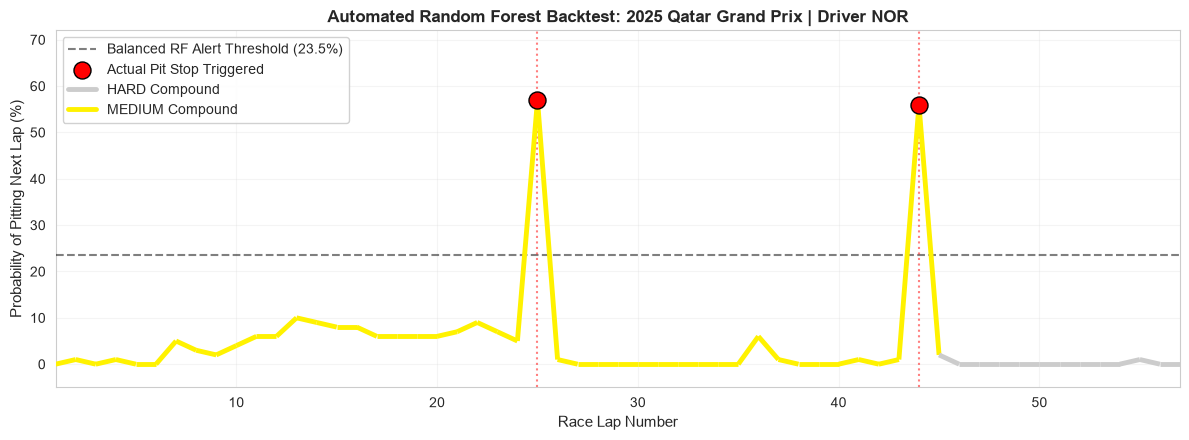

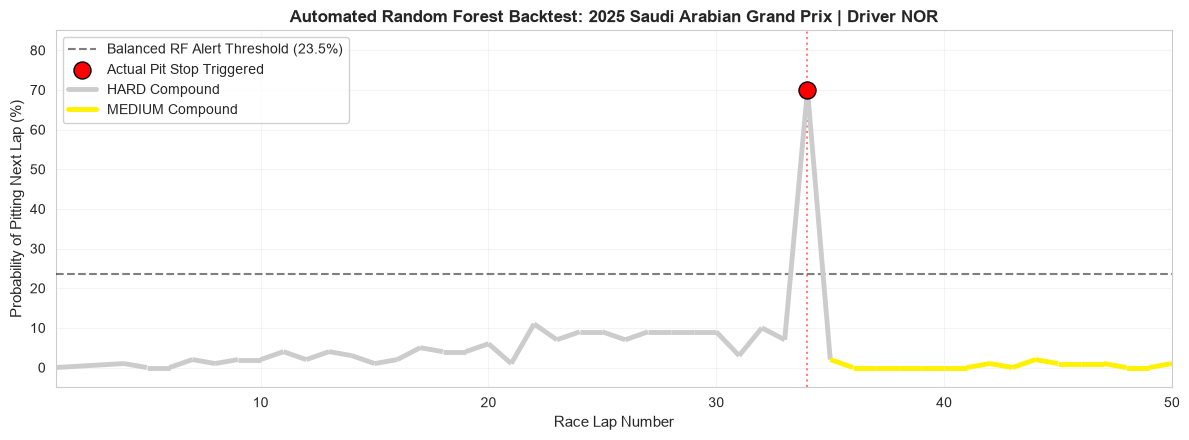

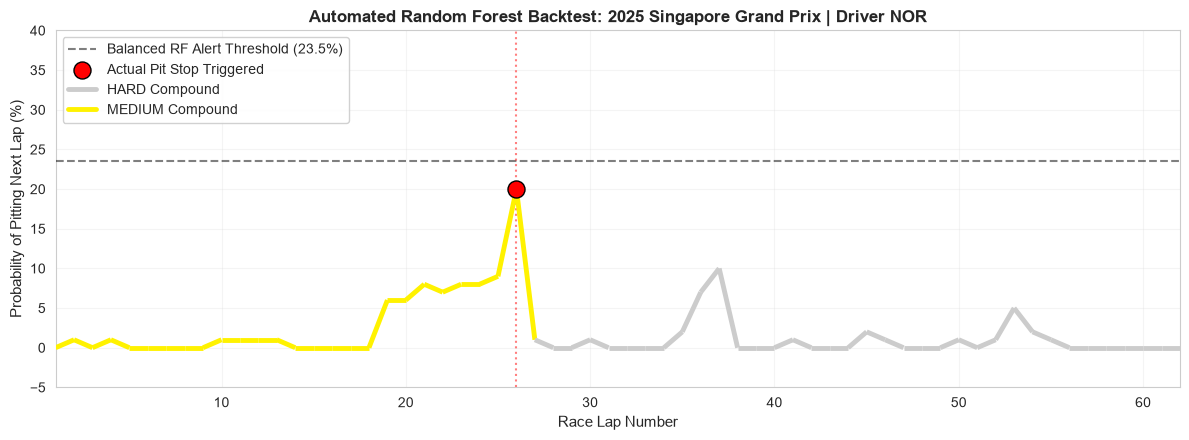

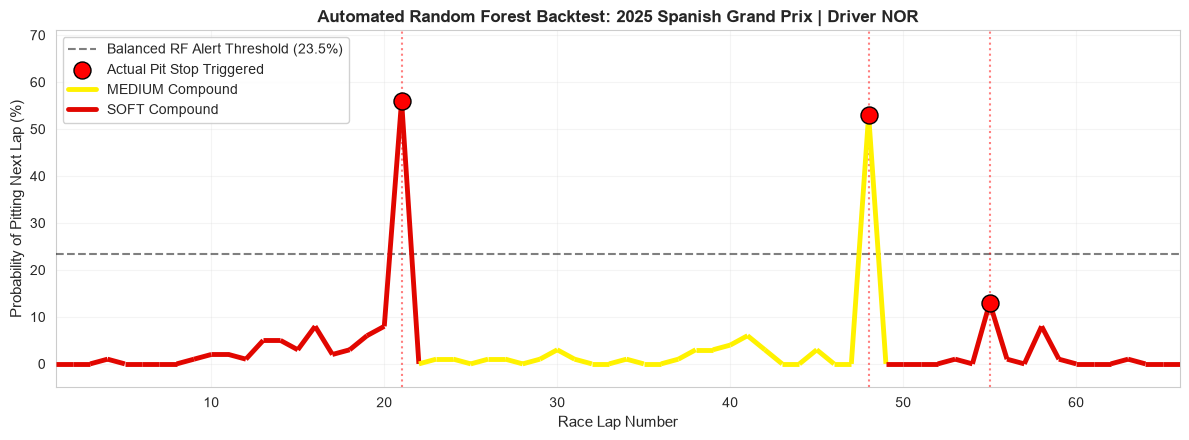

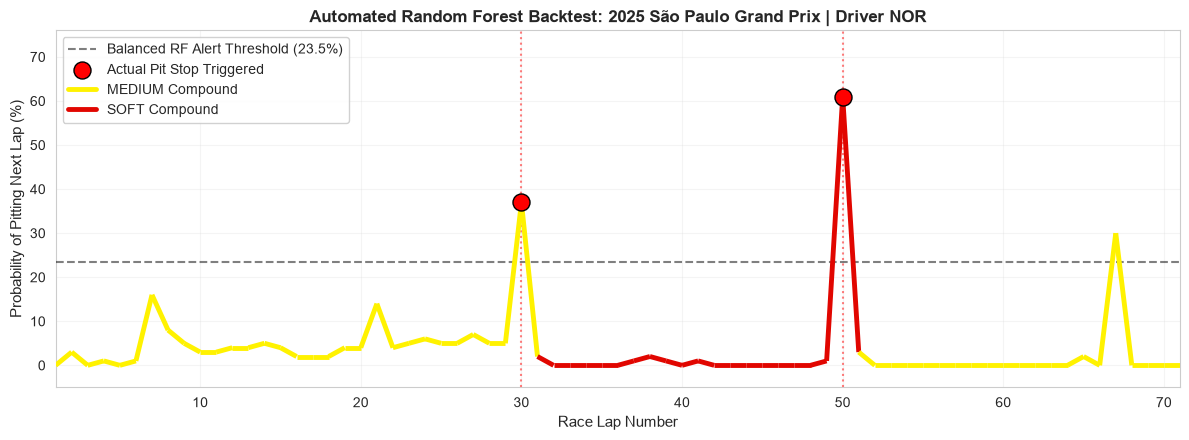

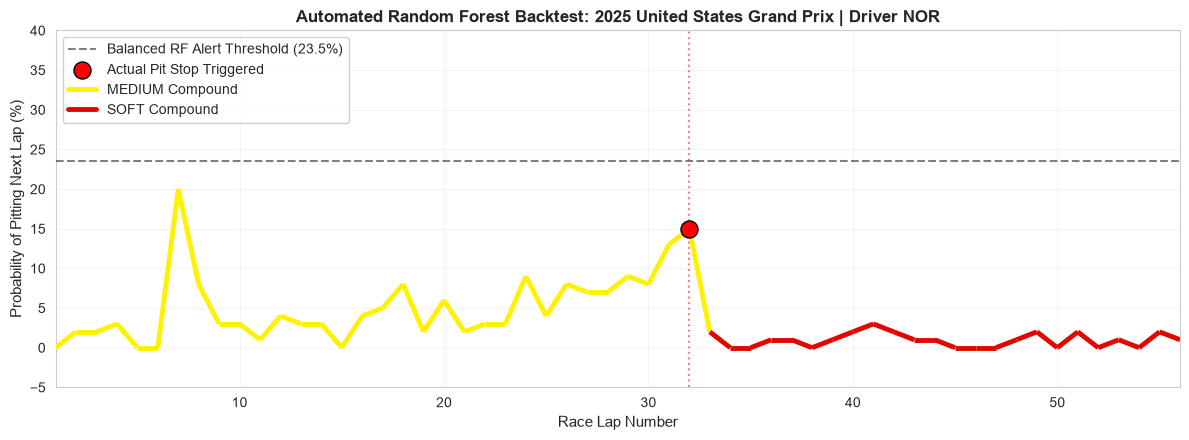

     RANDOM FOREST EVALUATION SUITE (RAW PREDICTIONS)


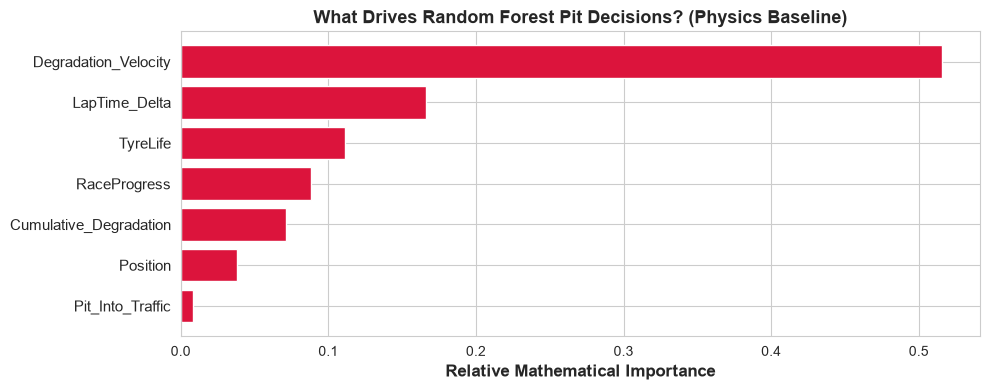

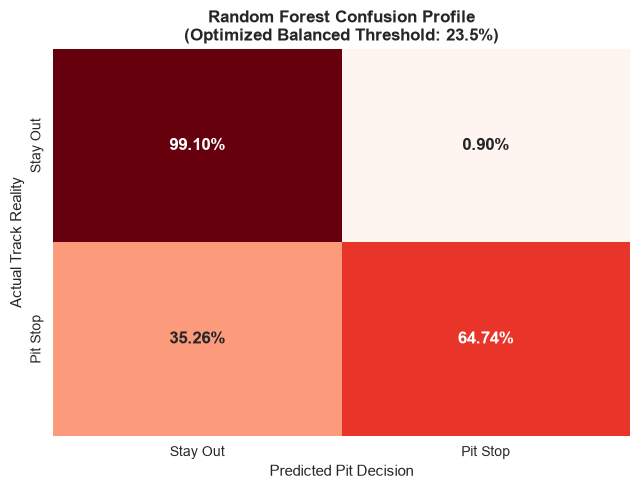


--- RANDOM FOREST PERFORMANCE SUMMARY LOG ---
              precision    recall  f1-score   support

    Stay Out       0.99      0.99      0.99     26331
    Pit Stop       0.66      0.65      0.65       709

    accuracy                           0.98     27040
   macro avg       0.82      0.82      0.82     27040
weighted avg       0.98      0.98      0.98     27040


     OPTION 1: EXPORT PREDICTIONS DATASET FOR MATLAB
✅ Exported dataset with 'PitProbability' column to: f1_strategy_dataset_with_predictions.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import fbeta_score, confusion_matrix, classification_report

# =========================================================================
# STEP 1: LOAD DATA & TRACK-WIDE DATASET CONFIGURATION
# =========================================================================
df_full = pd.read_csv('f1_strategy_dataset_v6.csv')

# Ensure rows are sorted chronologically within groups before rolling differentials
df_full = df_full.sort_values(by=['Year', 'Race', 'Driver', 'LapNumber']).reset_index(drop=True)

# Engineer Tyre Degradation Acceleration (Velocity delta layer)
df_full['Degradation_Velocity'] = df_full.groupby(['Year', 'Race', 'Driver'])['Cumulative_Degradation'].diff().fillna(0)

# --- ENGINEER PIT INTO TRAFFIC FEATURE (KAGGLE SPECIFIC SCHEMA) ---
print("Engineering trackside traffic window metrics...")

# Calculate cumulative race time per driver using exact Kaggle column name
df_full['Total_Race_Time'] = df_full.groupby(['Year', 'Race', 'Driver'])['LapTime (s)'].cumsum()

# Target landing zone time position assuming an average 22-second pit loss
PIT_LOSS_SECONDS = 22.0
GAP_THRESHOLD = 2.5
df_full['Post_Pit_Time_Target'] = df_full['Total_Race_Time'] - PIT_LOSS_SECONDS

traffic_flags = []
# Group by event to map out track layouts sequentially
for (year, race), group in df_full.groupby(['Year', 'Race']):
    position_matrix = group.pivot(index='LapNumber', columns='Driver', values='Total_Race_Time')

    for row in group.itertuples():
        current_lap = row.LapNumber
        target_time = row.Post_Pit_Time_Target

        if current_lap in position_matrix.index:
            other_cars_times = position_matrix.loc[current_lap].dropna().values
            # Compute how many cars fall into the ±2.5s window of our projected pit exit
            cars_in_window = np.sum(np.abs(other_cars_times - target_time) <= GAP_THRESHOLD)
            traffic_flags.append(cars_in_window)
        else:
            traffic_flags.append(0)

df_full['Cars_In_Pit_Window'] = traffic_flags
df_full['Pit_Into_Traffic'] = np.where(df_full['Cars_In_Pit_Window'] > 0, 1, 0)

# Upgraded physics baseline features list (Now including Traffic Metrics!)
features = ['TyreLife', 'Cumulative_Degradation', 'Degradation_Velocity',
            'LapTime_Delta', 'RaceProgress', 'Position', 'Pit_Into_Traffic']

# AUTO-DETECTION SCHEMA: Scans for Kaggle naming variations
possible_tyre_cols = ['Compound_Encoded', 'Compound', 'TyreCompound', 'Tyre']
tyre_col = None
for col in possible_tyre_cols:
    if col in df_full.columns:
        tyre_col = col
        print(f"-> Successfully mapped tyre telemetry data using database column: '{tyre_col}'")
        break

if tyre_col is None:
    print("⚠️ WARNING: No compound column found. Defaulting color segments to grey.")

# Standard F1 color palette mapping for downstream LineCollections
COMPOUND_COLORS = {
    'SOFT': '#E10600',          # F1 Racing Red
    'MEDIUM': '#FFF200',        # Pirelli Yellow
    'HARD': '#CCCCCC',          # Light Grey
    'INTERMEDIATE': '#43B02A',  # Green
    'WET': '#00A3E0',           # Blue
    'UNKNOWN': '#808080'        # Fallback Grey
}

# --- VECTORIZED COMPOUND MAPPING ---
if tyre_col:
    compound_map = {
        '0': 'HARD', 'H': 'HARD', 'HARD': 'HARD',
        '1': 'MEDIUM', 'M': 'MEDIUM', 'MEDIUM': 'MEDIUM',
        '2': 'SOFT', 'S': 'SOFT', 'SOFT': 'SOFT',
        '3': 'INTER', 'I': 'INTERMEDIATE', 'INTERMEDIATE': 'INTERMEDIATE',
        '4': 'WET', 'W': 'WET', 'WET': 'WET'
    }
    df_full['Clean_Compound'] = df_full[tyre_col].astype(str).str.split('.').str[0].str.strip().str.upper()
    df_full['Clean_Compound'] = df_full['Clean_Compound'].map(compound_map).fillna('UNKNOWN')
else:
    df_full['Clean_Compound'] = 'UNKNOWN'


# SOLVE CHRONOLOGICAL ISOLATION: Split historical training datasets from unseen 2025 deployment records
df_train_multi = df_full[df_full['Year'].isin([2022, 2023, 2024])].copy()
df_train_multi = df_train_multi.dropna(subset=features + ['PitNextLap'])

# --- GROUP-BASED SPLIT TO PREVENT LAP LEAKAGE ---
df_train_multi['Race_Group'] = df_train_multi['Year'].astype(str) + "_" + df_train_multi['Race']

unique_groups = df_train_multi['Race_Group'].unique()
np.random.seed(42)
val_groups = np.random.choice(unique_groups, size=int(len(unique_groups) * 0.2), replace=False)

train_mask = ~df_train_multi['Race_Group'].isin(val_groups)
val_mask = df_train_multi['Race_Group'].isin(val_groups)

X_tr_raw = df_train_multi.loc[train_mask, features]
y_tr = df_train_multi.loc[train_mask, 'PitNextLap']

X_val_raw = df_train_multi.loc[val_mask, features]
y_val = df_train_multi.loc[val_mask, 'PitNextLap']


# =========================================================================
# STEP 2: RANDOM FOREST TRAINING & THRESHOLD OPTIMIZATION
# =========================================================================
print("\n" + "="*70)
print("     RANDOM FOREST TRAINING & OPTIMIZATION")
print("="*70)

tree_counts = np.arange(1, 101, 5)
train_accuracies = []
val_accuracies = []

print("Growing Random Forest ensemble step-by-step and logging metrics...")
rf_tracker = RandomForestClassifier(class_weight='balanced', random_state=42, warm_start=True)

for trees in tree_counts:
    rf_tracker.n_estimators = trees
    rf_tracker.fit(X_tr_raw, y_tr)
    train_accuracies.append(rf_tracker.score(X_tr_raw, y_tr))
    val_accuracies.append(rf_tracker.score(X_val_raw, y_val))

# Fit Final 100-Tree Production Model
rf_model_multi = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model_multi.fit(X_tr_raw, y_tr)

# --- AUTOMATED BALANCED THRESHOLD SEARCH (BETA = 1.0) ---
rf_val_probs = rf_model_multi.predict_proba(X_val_raw)[:, 1] * 100
best_rf_threshold, best_rf_fbeta = 0.0, 0.0

for th in np.arange(1, 100, 0.5):
    preds = np.where(rf_val_probs >= th, 1, 0)
    fbeta = fbeta_score(y_val, preds, beta=1.0, zero_division=0)
    if fbeta > best_rf_fbeta:
        best_rf_fbeta, best_rf_threshold = fbeta, th

print(f"🏆 RF Balanced F1 Threshold Selected: {best_rf_threshold:.2f}% (Validation Peak F1: {best_rf_fbeta:.4f})")


# =========================================================================
# STEP 3: PREPARE CHRONOLOGICAL UNSEEN 2025 DEPLOYMENT SET
# =========================================================================
df_2025_test = df_full[df_full['Year'] == 2025].copy()
df_2025_test = df_2025_test.dropna(subset=features + ['PitNextLap'])
unique_2025_races = df_2025_test['Race'].unique()
target_driver = 'NOR'

print(f"\nExtracted {len(unique_2025_races)} valid tracks for 2025 campaign backtesting loops...")


# =========================================================================
# STEP 4: AUTOMATED DEPLOYMENT LOOP — RANDOM FOREST PLOTS (RAW TELEMETRY)
# =========================================================================
print(f"\n" + "-"*70)
print(f" -> LAUNCHING 2025 RUNTIME BACKTEST: RANDOM FOREST PLOTS")
print(f"-"*70)

for race_name in unique_2025_races:
    race_subset = df_2025_test[df_2025_test['Race'] == race_name]
    driver_df = race_subset[race_subset['Driver'] == target_driver].sort_values(by='LapNumber')

    if driver_df.empty:
        continue

    driver_features = driver_df[features]
    driver_probs = rf_model_multi.predict_proba(driver_features)[:, 1] * 100

    lap_numbers = driver_df['LapNumber'].values
    actual_pit_laps = driver_df['PitNextLap'].values
    compounds = driver_df['Clean_Compound'].values

    fig, ax = plt.subplots(figsize=(12, 4.5))

    # Vectorized Colored Line Collection
    points = np.array([lap_numbers, driver_probs]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    line_colors = [COMPOUND_COLORS.get(comp, '#808080') for comp in compounds[:-1]]
    lc = LineCollection(segments, colors=line_colors, linewidths=3.5, zorder=4)
    ax.add_collection(lc)

    ax.axhline(y=best_rf_threshold, color='black', linestyle='--', alpha=0.5, zorder=3,
               label=f"Balanced RF Alert Threshold ({best_rf_threshold:.1f}%)")

    # Plot actual mechanical trackside stops
    actual_pit_lap_indices = np.where(actual_pit_laps == 1)[0]
    for i, idx in enumerate(actual_pit_lap_indices):
        lap = lap_numbers[idx]
        lap_prob = driver_probs[idx]
        ax.axvline(x=lap, color='red', linestyle=':', alpha=0.5, zorder=3)
        label_text = 'Actual Pit Stop Triggered' if i == 0 else ""
        ax.scatter(lap, lap_prob, color='red', s=150, zorder=5, edgecolors='black', label=label_text)

    # Clean legends and render metadata canvas layers
    unique_race_compounds = np.unique(compounds)
    for comp in unique_race_compounds:
        if comp in COMPOUND_COLORS:
            ax.plot([], [], color=COMPOUND_COLORS[comp], linewidth=3.5, label=f'{comp} Compound')

    ax.set_title(f'Automated Random Forest Backtest: 2025 {race_name} | Driver {target_driver}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Race Lap Number', fontsize=11)
    ax.set_ylabel('Probability of Pitting Next Lap (%)', fontsize=11)
    ax.grid(True, alpha=0.2, zorder=1)

    # SAFEGUARD LIMIT CONSTRAINTS AGAINST EMPTY/NAN PROBABILITIES
    max_lap = max(lap_numbers.max(), 2) if len(lap_numbers) > 0 else 70
    max_prob = np.nanmax(driver_probs) if len(driver_probs) > 0 and not np.isnan(driver_probs).all() else 100

    ax.set_xlim(1, max_lap)
    ax.set_ylim(-5, min(max(max_prob, 25) + 15, 115))

    handles, labels_list = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_list, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', framealpha=0.9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


# =========================================================================
# EVALUATION SUITE
# =========================================================================
print("=" * 70)
print("     RANDOM FOREST EVALUATION SUITE (RAW PREDICTIONS)")
print("=" * 70)

# --- FEATURE IMPORTANCE ANALYSIS ---
importances = rf_model_multi.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 4))
plt.barh(range(len(indices)), importances[indices], align='center', color='crimson')
plt.yticks(range(len(indices)), [features[i] for i in indices], fontsize=11)
plt.xlabel('Relative Mathematical Importance', fontsize=12, fontweight='bold')
plt.title('What Drives Random Forest Pit Decisions? (Physics Baseline)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- CONFUSION MATRIX GENERATION ---
X_test_2025_rf = df_2025_test[features]
y_true_2025 = df_2025_test['PitNextLap'].values

# Inference probability arrays (0 to 100) using the updated precision threshold
rf_probs = rf_model_multi.predict_proba(X_test_2025_rf)[:, 1] * 100
rf_preds = np.where(rf_probs >= best_rf_threshold, 1, 0)

# Compute matrix percentages
rf_cm = confusion_matrix(y_true_2025, rf_preds, normalize='true')
labels = ['Stay Out', 'Pit Stop']

plt.figure(figsize=(6.5, 5))
sns.heatmap(rf_cm, annot=True, fmt='.2%', cmap='Reds', cbar=False,
            xticklabels=labels, yticklabels=labels, annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'Random Forest Confusion Profile\n(Optimized Balanced Threshold: {best_rf_threshold:.1f}%)', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Pit Decision', fontsize=11)
plt.ylabel('Actual Track Reality', fontsize=11)
plt.tight_layout()
plt.show()

print("\n--- RANDOM FOREST PERFORMANCE SUMMARY LOG ---")
print(classification_report(y_true_2025, rf_preds, target_names=labels, zero_division=0))


# =========================================================================
# OPTION 1 IMPLEMENTATION: EXPORT PREDICTIONS TO CSV FOR MATLAB
# =========================================================================
print("\n" + "="*70)
print("     OPTION 1: EXPORT PREDICTIONS DATASET FOR MATLAB")
print("="*70)

# 1. Fill missing feature values with 0 for whole dataset prediction safety
df_full_clean = df_full.copy()
X_full = df_full_clean[features].fillna(0)

# 2. Predict probability of pitting for all rows (0 to 100 scale)
df_full['PitProbability'] = rf_model_multi.predict_proba(X_full)[:, 1] * 100

# 3. Export dataset containing 'PitProbability' to CSV
output_csv = 'f1_strategy_dataset_with_predictions.csv'
df_full.to_csv(output_csv, index=False)
print(f"✅ Exported dataset with 'PitProbability' column to: {output_csv}")